---
## 1. Setup

In [1]:
!pip install transformers accelerate -q

import numpy as np
import pandas as pd
import re
import os
import gc
import time
import warnings
import unicodedata
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import scipy.sparse as sp
from scipy.sparse import csr_matrix

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.amp import autocast, GradScaler

import psutil

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = False
START_TIME = time.time()

print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    cap = torch.cuda.get_device_capability()
    print(f'Compute Capability: sm_{cap[0]}{cap[1]}')

def elapsed():
    """In thời gian đã chạy từ đầu."""
    t = time.time() - START_TIME
    h, m, s = int(t//3600), int((t%3600)//60), int(t%60)
    print(f'Elapsed: {h:02d}h {m:02d}m {s:02d}s')

def ram_usage():
    p = psutil.Process(os.getpid())
    print(f'RAM: {p.memory_info().rss/1e9:.2f} GB')
    if DEVICE.type == 'cuda':
        print(f'VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB')

Device: cuda
GPU: Tesla T4
Compute Capability: sm_75


---
## 2. Load Data

In [2]:
DATA_DIR = '/kaggle/input/datasets/namnguynnnn/sentence-classification/Dataset/'
train = pd.read_csv(DATA_DIR + 'train.csv')
test  = pd.read_csv(DATA_DIR + 'test.csv')

train['Text'] = train['Text'].fillna('')
test['Text']  = test['Text'].fillna('')

n_before = len(train)
train = train.drop_duplicates(subset=['Text']).reset_index(drop=True)
print(f'Train: {train.shape} | Test: {test.shape}')
print(f'Removed {n_before - len(train)} duplicates')
display(train.head(3))
elapsed()

Train: (560000, 2) | Test: (38000, 2)
Removed 0 duplicates


,Label,Text
0,0,"Unfortunately, the frustration of being Dr. Go..."
1,1,Been going to Dr. Goldberg for over 10 years. ...
2,0,I don't know what Dr. Goldberg was like before...


Elapsed: 00h 00m 07s


---
## 3. EDA 


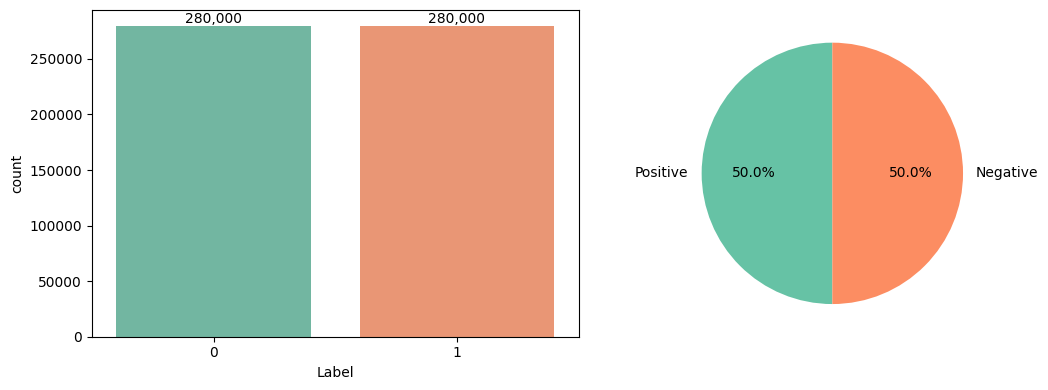

Imbalance ratio: 1.00
Balanced
 50th pct word count: 97
 90th pct word count: 282
 95th pct word count: 372
 99th pct word count: 608


0

In [3]:
label_counts = train['Label'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x='Label', data=train, palette='Set2', ax=axes[0])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')
label_counts.plot.pie(autopct='%1.1f%%', ax=axes[1],
                      labels=['Positive','Negative'],
                      colors=['#66c2a5','#fc8d62'], startangle=90)
axes[1].set_ylabel('')
plt.tight_layout(); plt.show()

ratio = label_counts.max() / label_counts.min()
print(f'Imbalance ratio: {ratio:.2f}')
print('Balanced' if ratio < 1.5 else 'Imbalanced')

word_count = train['Text'].map(lambda x: len(x.split()))
for pct in [50, 90, 95, 99]:
    print(f'{pct:3}th pct word count: {np.percentile(word_count, pct):.0f}')
del word_count; gc.collect()

In [4]:
STOPWORDS  = set(stopwords.words('english'))
KEEP_WORDS = {'not', 'no', 'never', 'neither', 'nor', 'hardly', 'barely',
              "n't", 'nobody', 'nothing'}
STOPWORDS -= KEEP_WORDS

CONTRACTIONS = {
    "don't":"do not","doesn't":"does not","didn't":"did not",
    "won't":"will not","wouldn't":"would not","can't":"cannot",
    "couldn't":"could not","shouldn't":"should not",
    "isn't":"is not","aren't":"are not","wasn't":"was not",
    "weren't":"were not","hadn't":"had not","hasn't":"has not",
    "haven't":"have not","mustn't":"must not","needn't":"need not",
    "it's":"it is","he's":"he is","she's":"she is",
    "i've":"i have","i'm":"i am","i'll":"i will","i'd":"i would",
    "that's":"that is","there's":"there is","they're":"they are",
    "we're":"we are","you're":"you are","they've":"they have",
}

NEGATION_WORDS = {'not', "n't", 'no', 'never', 'neither', 'nobody', 'nothing'}
NEGATION_WINDOW = 3
PUNCT = {'.', ',', '!', '?', ';', ':'}


def handle_negation_fast(text: str, window_size: int = 3) -> str:
    """
    Regex-based negation — nhanh hơn word_tokenize 50x.
    Dùng re.findall thay vì nltk.word_tokenize.
    """
    # Split giữ dấu câu như token riêng để reset đúng
    tokens = re.findall(r"[a-z0-9']+|[.,!?;:]", text)
    result = []
    negate_count = 0

    for token in tokens:
        # Dấu câu → reset negation window
        if token in PUNCT:
            negate_count = 0
            # Bỏ dấu câu khỏi output (sẽ bị bước 7 xóa dù sao)
            continue

        is_negation = (token in NEGATION_WORDS or token.endswith("n't"))
        if is_negation:
            result.append(token)
            negate_count = window_size
        elif negate_count > 0:
            result.append(f'not_{token}')  # chữ thường để không bị xóa
            negate_count -= 1
        else:
            result.append(token)

    return ' '.join(result)


def clean_text_for_tfidf(text: str) -> str:
    """Pipeline preprocessing cho TF-IDF. KHÔNG dùng cho BERT."""
    if not isinstance(text, str): return ''

    # 1. Unicode normalization
    text = unicodedata.normalize('NFKC', text)
    text = ' '.join(text.split())

    # 2. Lowercase
    text = text.lower()

    # 3. Bỏ URL, HTML
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)

    # 4. Expand contractions
    for c, f in CONTRACTIONS.items():
        text = text.replace(c, f)

    # 5. Replace numbers bằng 'num' (chữ thường)
    text = re.sub(r'\d+', 'num', text)

    # 6. Negation handling bằng REGEX — không dùng word_tokenize
    text = handle_negation_fast(text, window_size=NEGATION_WINDOW)

    # 7. Xóa ký tự đặc biệt (giữ _ cho not_xxx)
    text = re.sub(r'[^a-z0-9_\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# Verify output
test_cases = [
    "I do not like this product at all!",
    "This isn't good enough for the price.",
    "I spent $200 and it's totally worth it!",
    "AMAZING service! The staff was so helpful.",
    "Terrible. Never buying again.",
]
print('=== Negation Handling Demo ===')
for t in test_cases:
    print(f'BEFORE: {t}')
    print(f'AFTER:  {clean_text_for_tfidf(t)}')
    print()

=== Negation Handling Demo ===
BEFORE: I do not like this product at all!
AFTER:  i do not not_like not_this not_product at all

BEFORE: This isn't good enough for the price.
AFTER:  this is not not_good not_enough not_for the price

BEFORE: I spent $200 and it's totally worth it!
AFTER:  i spent num and it is totally worth it

BEFORE: AMAZING service! The staff was so helpful.
AFTER:  amazing service the staff was so helpful

BEFORE: Terrible. Never buying again.
AFTER:  terrible never not_buying not_again



In [5]:
import time

sample_100 = train['Text'].iloc[:100]
t0 = time.time()
sample_100.apply(clean_text_for_tfidf)
rate = 100 / (time.time() - t0)
estimated_min = len(train) / rate / 60

print(f'Tốc độ:          {rate:.0f} mẫu/giây')
print(f'Ước tính train:  {estimated_min:.1f} phút ({len(train):,} mẫu)')
print(f'Ước tính test:   {len(test)/rate/60:.1f} phút ({len(test):,} mẫu)')
print()
if estimated_min > 60:
    print('Vẫn chậm → cân nhắc tắt negation handling')
else:
    print('Tốc độ hợp lý')

Tốc độ:          4953 mẫu/giây
Ước tính train:  1.9 phút (560,000 mẫu)
Ước tính test:   0.1 phút (38,000 mẫu)

Tốc độ hợp lý


In [6]:
# Apply preprocessing
print('Preprocessing train...')
t0 = time.time()
train['clean_text'] = train['Text'].apply(clean_text_for_tfidf)
print(f'Train done: {time.time()-t0:.0f}s')

print('Preprocessing test...')
t0 = time.time()
test['clean_text'] = test['Text'].apply(clean_text_for_tfidf)
print(f'Test done: {time.time()-t0:.0f}s')

print(f'\nSample:')
print(f'ORIG:  {train["Text"].iloc[0][:80]}')
print(f'CLEAN: {train["clean_text"].iloc[0][:80]}')
ram_usage()
elapsed()

Preprocessing train...
Train done: 101s
Preprocessing test...
Test done: 7s

Sample:
ORIG:  Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of th
CLEAN: unfortunately the frustration of being dr goldberg s patient is a repeat of the 
RAM: 1.95 GB
VRAM: 0.00 GB
Elapsed: 00h 02m 00s


---
## 5. Meta-Features

In [7]:
def extract_meta_features(df: pd.DataFrame) -> np.ndarray:
    feats = pd.DataFrame()
    feats['word_count']     = df['Text'].map(lambda x: len(x.split()))
    feats['char_count']     = df['Text'].map(len)
    feats['avg_word_len']   = df['Text'].map(
        lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
    )
    feats['exclaim_count']  = df['Text'].str.count(r'!')
    feats['question_count'] = df['Text'].str.count(r'\?')
    feats['ellipsis_count'] = df['Text'].str.count(r'\.\.\.')
    neg_pattern = r"\b(not|no|never|neither|hardly|barely|n't)\b"
    feats['negation_count'] = df['Text'].str.lower().str.count(neg_pattern)
    feats['caps_ratio']     = df['Text'].map(
        lambda x: sum(1 for w in x.split() if w.isupper() and len(w)>1) / max(len(x.split()),1)
    )
    feats['title_ratio']    = df['Text'].map(
        lambda x: sum(1 for w in x.split() if w.istitle()) / max(len(x.split()),1)
    )
    feats['dr_mentions']    = df['Text'].str.lower().str.count(r'\bdr\.?\b')
    feats['year_mentions']  = df['Text'].str.count(r'\d+\s*years?')
    feats['star_mentions']  = df['Text'].str.count(r'\b[1-5]\s*stars?\b')
    return feats.fillna(0).values

meta_train = extract_meta_features(train)
meta_test  = extract_meta_features(test)
print(f'Meta-features: {meta_train.shape}')
elapsed()

Meta-features: (560000, 12)
Elapsed: 00h 03m 19s


---
## 6. TF-IDF + ML Baseline

In [8]:
print('Creating TF-IDF features...')
t0 = time.time()

vec_word = TfidfVectorizer(
    ngram_range=(1, 2), max_features=30_000,
    sublinear_tf=True, min_df=2,
    analyzer='word', dtype=np.float32
)
vec_char = TfidfVectorizer(
    ngram_range=(3, 4), max_features=20_000,
    sublinear_tf=True, min_df=2,
    analyzer='char_wb', dtype=np.float32
)

X_train_w = vec_word.fit_transform(train['clean_text'])
X_test_w  = vec_word.transform(test['clean_text'])
X_train_c = vec_char.fit_transform(train['clean_text'])
X_test_c  = vec_char.transform(test['clean_text'])

X_train_tfidf = sp.hstack([X_train_w, X_train_c], format='csr')
X_test_tfidf  = sp.hstack([X_test_w,  X_test_c],  format='csr')
del X_train_w, X_train_c, X_test_w, X_test_c
gc.collect()

scaler = StandardScaler()
meta_train_scaled = scaler.fit_transform(meta_train)
meta_test_scaled  = scaler.transform(meta_test)

X_train_full = sp.hstack([X_train_tfidf, csr_matrix(meta_train_scaled)], format='csr')
X_test_full  = sp.hstack([X_test_tfidf,  csr_matrix(meta_test_scaled)],  format='csr')

y_train = train['Label'].values

print(f'Feature shape: {X_train_full.shape}')
print(f'TF-IDF done: {time.time()-t0:.0f}s')
ram_usage(); elapsed()

Creating TF-IDF features...
Feature shape: (560000, 50012)
TF-IDF done: 438s
RAM: 11.68 GB
VRAM: 0.00 GB
Elapsed: 00h 10m 37s


In [9]:
# Cross-validation — n_jobs=1 để tránh OOM
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

models = {
    'Logistic Regression': LogisticRegression(
        C=3, max_iter=500, solver='saga', class_weight='balanced'
    ),
    'LinearSVC': CalibratedClassifierCV(
        LinearSVC(C=0.5, max_iter=2000, class_weight='balanced'), cv=3
    )
}

print('Cross-Validation...\n')
results = {}

for name, model in models.items():
    t0 = time.time()
    scores = cross_val_score(
        model, X_train_full, y_train,
        cv=skf, scoring='f1_macro', n_jobs=1
    )
    results[name] = scores
    print(f'{name}:')
    print(f'  F1: {scores.mean():.4f} ± {scores.std():.4f}  ({time.time()-t0:.0f}s)')

best_name = max(results, key=lambda k: results[k].mean())
best_ml   = models[best_name]
best_ml.fit(X_train_full, y_train)
baseline_probs = best_ml.predict_proba(X_test_full)

print(f'\nBest baseline: {best_name} | F1={results[best_name].mean():.4f}')
elapsed()

Cross-Validation...

Logistic Regression:
  F1: 0.9075 ± 0.0123  (7119s)
LinearSVC:
  F1: 0.9554 ± 0.0004  (829s)

Best baseline: LinearSVC | F1=0.9554
Elapsed: 02h 30m 28s


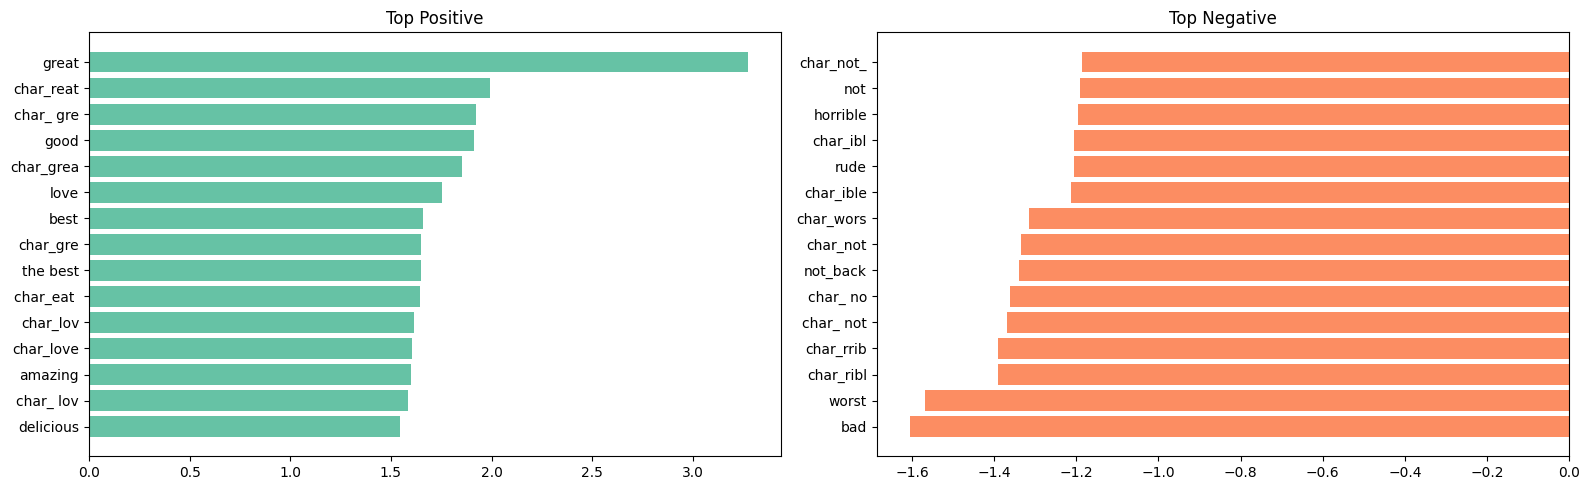

not_ features learned: 1761
                feature     coef
       not_disappointed 0.688946
                not_too 0.612066
                not_had 0.462085
                not_bad 0.404768
         not_disappoint 0.296185
not_be not_disappointed 0.295901
          not_a not_bad 0.277693
               not_been 0.265599
          not_had not_a 0.261849
               not_only 0.256652


In [10]:
# Feature Importance
if 'Logistic Regression' in best_name:
    lr_model = best_ml
else:
    lr_model = LogisticRegression(C=3, max_iter=500, solver='saga', class_weight='balanced')
    lr_model.fit(X_train_full, y_train)

word_features = list(vec_word.get_feature_names_out())
char_features = [f'char_{f}' for f in vec_char.get_feature_names_out()]
meta_names = ['word_count','char_count','avg_word_len','exclaim_count',
              'question_count','ellipsis_count','negation_count',
              'caps_ratio','title_ratio','dr_mentions','year_mentions','star_mentions']
all_features = word_features + char_features + meta_names

coef = lr_model.coef_[0]
feature_df = pd.DataFrame({'feature': all_features[:len(coef)], 'coef': coef})\
             .sort_values('coef', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, df_sub, title, color in [
    (axes[0], feature_df.head(15), 'Top Positive', '#66c2a5'),
    (axes[1], feature_df.tail(15), 'Top Negative', '#fc8d62'),
]:
    ax.barh(df_sub['feature'], df_sub['coef'], color=color)
    ax.set_title(title)
    ax.invert_yaxis()
plt.tight_layout(); plt.show()

not_feats = feature_df[feature_df['feature'].str.startswith('not_')]
print(f'not_ features learned: {len(not_feats)}')
if not not_feats.empty:
    print(not_feats.head(10).to_string(index=False))

In [11]:
# Xóa TF-IDF columns trước BERT
train.drop(columns=['clean_text'], inplace=True, errors='ignore')
test.drop(columns=['clean_text'],  inplace=True, errors='ignore')
del X_train_tfidf, X_test_tfidf, meta_train_scaled, meta_test_scaled
gc.collect()

MODEL_NAME   = 'distilbert-base-uncased'
MAX_LEN      = 128
BATCH_SIZE   = 64    # ← tăng từ 32 lên 64 để ít batches hơn
EPOCHS       = 2     # ← giảm từ 3 xuống 2
LR           = 3e-5
WARMUP_RATIO = 0.02
N_FOLDS      = 1     # ← giảm từ 3 xuống 1

print(f'Model:      {MODEL_NAME}')
print(f'MAX_LEN:    {MAX_LEN}')
print(f'BATCH_SIZE: {BATCH_SIZE}')
print(f'EPOCHS:     {EPOCHS}')
print(f'N_FOLDS:    {N_FOLDS}  ← key change: 1 fold để fit trong 12h')
print(f'LR:         {LR}')

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('✅ Tokenizer loaded')

# Ước tính thời gian
n_train = int(len(train) * (N_FOLDS-1)/N_FOLDS) if N_FOLDS > 1 else int(len(train) * 0.85)
n_batches_per_epoch = n_train // BATCH_SIZE
sec_per_batch = 0.08  # T4 ước tính
total_min = n_batches_per_epoch * EPOCHS * N_FOLDS * sec_per_batch / 60
print(f'\nƯớc tính BERT training: {total_min:.0f} phút ({total_min/60:.1f} giờ)')

Model:      distilbert-base-uncased
MAX_LEN:    128
BATCH_SIZE: 64
EPOCHS:     2
N_FOLDS:    1  ← key change: 1 fold để fit trong 12h
LR:         3e-05


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer loaded

Ước tính BERT training: 20 phút (0.3 giờ)


In [12]:
def token_dropout(text: str, p: float = 0.05) -> str:
    """Randomly drop tokens — augmentation nhẹ."""
    tokens = text.split()
    kept = [t for t in tokens if np.random.random() > p]
    return ' '.join(kept) if kept else (tokens[0] if tokens else '')


class ReviewDataset(Dataset):
    def __init__(self, texts, labels=None, augment=False, dropout_prob=0.05):
        self.texts        = list(texts)
        self.labels       = list(labels) if labels is not None else None
        self.augment      = augment
        self.dropout_prob = dropout_prob

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        if self.augment:
            text = token_dropout(text, self.dropout_prob)
        enc = tokenizer(
            text, max_length=MAX_LEN,
            padding='max_length', truncation=True,
            return_tensors='pt'
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

print('ReviewDataset ready')

ReviewDataset ready


In [13]:
scaler_amp = GradScaler('cuda', enabled=USE_AMP)

def train_one_epoch(model, loader, optimizer, scheduler, epoch_num, fold_num):
    model.train()
    total_loss = 0
    n_batches  = len(loader)
    t0 = time.time()

    for i, batch in enumerate(loader):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        with autocast(device_type='cuda', enabled=USE_AMP):
            loss = model(**batch).loss
        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler_amp.step(optimizer)
        scaler_amp.update()
        scheduler.step()
        optimizer.zero_grad(set_to_none=True)
        total_loss += loss.item()

        # Log mỗi 10%
        if (i + 1) % max(1, n_batches // 10) == 0:
            pct  = (i+1) / n_batches * 100
            rem  = (time.time()-t0) / (i+1) * (n_batches-i-1) / 60
            print(f'    [{i+1}/{n_batches}] {pct:.0f}% | loss={loss.item():.4f} | ETA={rem:.1f}min')

    return total_loss / n_batches


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_probs = [], []
    for batch in loader:
        inputs = {k: v.to(DEVICE) for k, v in batch.items() if k != 'labels'}
        with autocast(device_type='cuda', enabled=USE_AMP):
            logits = model(**inputs).logits
        probs = torch.softmax(logits.float(), dim=-1)
        all_preds.extend(logits.argmax(-1).cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return np.array(all_preds), np.array(all_probs)

print('Training functions ready')

Training functions ready


In [14]:
texts_all  = train['Text'].values
labels_all = train['Label'].values
texts_test = test['Text'].values

oof_preds       = np.zeros(len(train), dtype=int)
oof_probs       = np.zeros((len(train), 2))
test_probs_list = []

skf = StratifiedKFold(n_splits=max(N_FOLDS, 3), shuffle=True, random_state=SEED)

for fold, (tr_idx, val_idx) in enumerate(skf.split(texts_all, labels_all)):
    if fold >= N_FOLDS:   # Chỉ chạy N_FOLDS fold đầu
        break

    print(f'\n{"="*60}')
    print(f'FOLD {fold+1}/{N_FOLDS}  |  train={len(tr_idx):,}  val={len(val_idx):,}')
    print(f'{"="*60}')
    ram_usage(); elapsed()

    tr_loader = DataLoader(
        ReviewDataset(texts_all[tr_idx], labels_all[tr_idx],
                      augment=True, dropout_prob=0.05),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        ReviewDataset(texts_all[val_idx], labels_all[val_idx]),
        batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True
    )
    test_loader = DataLoader(
        ReviewDataset(texts_test),
        batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2
    ).to(DEVICE)

    optimizer    = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    total_steps  = len(tr_loader) * EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)
    scheduler    = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    best_f1, best_state = 0, None

    for epoch in range(EPOCHS):
        print(f'\n  Epoch {epoch+1}/{EPOCHS}')
        t_ep = time.time()
        avg_loss = train_one_epoch(model, tr_loader, optimizer, scheduler, epoch, fold)

        val_preds, _ = evaluate(model, val_loader)
        f1 = f1_score(labels_all[val_idx], val_preds, average='macro')
        ep_time = (time.time() - t_ep) / 60
        print(f'  → loss={avg_loss:.4f}  val_F1={f1:.4f}  ({ep_time:.1f}min)')

        if f1 > best_f1:
            best_f1 = f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f'New best: {best_f1:.4f}')

            torch.save(best_state, f'/kaggle/working/fold{fold}_best.pt')
            print(f'Checkpoint saved')

    # Predict với best model
    model.load_state_dict(best_state)
    model.to(DEVICE)
    oof_preds[val_idx], oof_probs[val_idx] = evaluate(model, val_loader)
    _, test_probs = evaluate(model, test_loader)
    test_probs_list.append(test_probs)

    fold_f1 = f1_score(labels_all[val_idx], oof_preds[val_idx], average='macro')
    print(f'\n  Fold {fold+1} Final F1: {fold_f1:.4f}')

    del model, optimizer, scheduler, best_state
    del tr_loader, val_loader, test_loader
    torch.cuda.empty_cache(); gc.collect()
    ram_usage(); elapsed()

valid_mask = oof_probs.sum(axis=1) > 0
oof_f1 = f1_score(labels_all[valid_mask], oof_preds[valid_mask], average='macro')
print(f'\n{"="*60}')
print(f'OOF F1-macro (BERT {N_FOLDS}-fold): {oof_f1:.4f}')
print(f'{"="*60}')
elapsed()


FOLD 1/1  |  train=373,333  val=186,667
RAM: 8.02 GB
VRAM: 0.00 GB
Elapsed: 03h 30m 12s


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  Epoch 1/2
    [583/5834] 10% | loss=0.2335 | ETA=60.5min
    [1166/5834] 20% | loss=0.2092 | ETA=54.3min
    [1749/5834] 30% | loss=0.2319 | ETA=47.7min
    [2332/5834] 40% | loss=0.1942 | ETA=41.0min
    [2915/5834] 50% | loss=0.1023 | ETA=34.2min
    [3498/5834] 60% | loss=0.0693 | ETA=27.4min
    [4081/5834] 70% | loss=0.0779 | ETA=20.6min
    [4664/5834] 80% | loss=0.0600 | ETA=13.7min
    [5247/5834] 90% | loss=0.0571 | ETA=6.9min
    [5830/5834] 100% | loss=0.1230 | ETA=0.0min
  → loss=0.1719  val_F1=0.9506  (80.7min)
New best: 0.9506
Checkpoint saved

  Epoch 2/2
    [583/5834] 10% | loss=0.0428 | ETA=61.7min
    [1166/5834] 20% | loss=0.0889 | ETA=54.9min
    [1749/5834] 30% | loss=0.1301 | ETA=48.0min
    [2332/5834] 40% | loss=0.1328 | ETA=41.2min
    [2915/5834] 50% | loss=0.0821 | ETA=34.3min
    [3498/5834] 60% | loss=0.0872 | ETA=27.5min
    [4081/5834] 70% | loss=0.0437 | ETA=20.6min
    [4664/5834] 80% | loss=0.0441 | ETA=13.8min
    [5247/5834] 90% | loss=0.1038 | E

---
## 8. Evaluation & Error Analysis

=== BERT OOF Evaluation ===
              precision    recall  f1-score   support

Negative (0)       0.96      0.95      0.95     93334
Positive (1)       0.95      0.96      0.95     93333

    accuracy                           0.95    186667
   macro avg       0.95      0.95      0.95    186667
weighted avg       0.95      0.95      0.95    186667



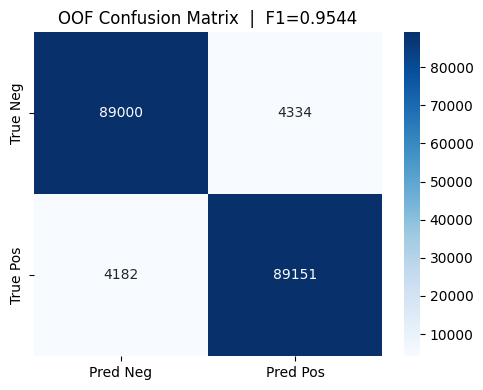

In [15]:
print('=== BERT OOF Evaluation ===')
print(classification_report(labels_all[valid_mask], oof_preds[valid_mask],
      target_names=['Negative (0)', 'Positive (1)']))

cm = confusion_matrix(labels_all[valid_mask], oof_preds[valid_mask])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Neg','Pred Pos'],
            yticklabels=['True Neg','True Pos'], ax=ax)
ax.set_title(f'OOF Confusion Matrix  |  F1={oof_f1:.4f}')
plt.tight_layout(); plt.show()

In [16]:
# Error Analysis
error_df = pd.DataFrame({
    'Text':       train['Text'].iloc[valid_mask.nonzero()[0]].values,
    'Label':      labels_all[valid_mask],
    'oof_pred':   oof_preds[valid_mask],
    'confidence': oof_probs[valid_mask].max(axis=1),
})
error_df['is_wrong'] = error_df['Label'] != error_df['oof_pred']
errors = error_df[error_df['is_wrong']].sort_values('confidence', ascending=False)

print(f'Errors: {len(errors)} / {len(error_df)} ({len(errors)/len(error_df)*100:.1f}%)')
print(f'False Pos: {(errors["oof_pred"]==1).sum()}  |  False Neg: {(errors["oof_pred"]==0).sum()}')

print('\n--- Top 5 Confident Errors ---')
for _, r in errors.head(5).iterrows():
    print(f'Text: {r["Text"][:100]}...')
    print(f'True={r["Label"]} | Pred={r["oof_pred"]} | Conf={r["confidence"]:.3f}\n')

del error_df; gc.collect()

Errors: 8516 / 186667 (4.6%)
False Pos: 4334  |  False Neg: 4182

--- Top 5 Confident Errors ---
Text: This store definitely has the worst customer service I've ever encountered - employees are uninforme...
True=1 | Pred=0 | Conf=1.000

Text: I went to have lunch with 2 other women. They had a long line and staff clearly can not handle it. V...
True=1 | Pred=0 | Conf=1.000

Text: This is the worse place to have any event  we went for wedding on 12/10  /13 it was so cold  service...
True=1 | Pred=0 | Conf=1.000

Text: House of brews?? Ehh.....standard at best.  Just because you have 20+ taps, doesnt mean you need 10 ...
True=1 | Pred=0 | Conf=1.000

Text: I had an amazing experience with the new veterinarian. Her name is  Pamela Boyd.She is amazing.She t...
True=0 | Pred=1 | Conf=1.000



18

---
## 9. Submission

In [17]:
# Ensemble
test_avg_probs = np.stack(test_probs_list, axis=-1).mean(axis=-1)

# BERT + Baseline ensemble
BERT_WEIGHT = 0.80
ML_WEIGHT   = 0.20
ensemble_probs = BERT_WEIGHT * test_avg_probs + ML_WEIGHT * baseline_probs

# Threshold tuning trên OOF
best_thr, best_thr_f1 = 0.5, 0.0
for thr in np.arange(0.3, 0.71, 0.01):
    preds = (oof_probs[valid_mask, 1] >= thr).astype(int)
    f1 = f1_score(labels_all[valid_mask], preds, average='macro')
    if f1 > best_thr_f1:
        best_thr_f1 = f1
        best_thr    = thr

print(f'Default threshold 0.5:    F1={oof_f1:.4f}')
print(f'Optimal threshold {best_thr:.2f}: F1={best_thr_f1:.4f} (+{(best_thr_f1-oof_f1)*100:.2f}%)')

final_preds = (ensemble_probs[:, 1] >= best_thr).astype(int)

submission = pd.DataFrame({'ID': range(0, len(test)), 'Label': final_preds})
submission.to_csv('submission.csv', index=False)

print('\n=== Final Summary ===')
print(f'Baseline CV F1:  {results[best_name].mean():.4f}')
print(f'BERT OOF F1:     {oof_f1:.4f}')
print(f'Best threshold:  {best_thr:.2f} → F1={best_thr_f1:.4f}')
display(submission.head(5))
print(submission['Label'].value_counts())
elapsed()

Default threshold 0.5:    F1=0.9544
Optimal threshold 0.48: F1=0.9545 (+0.02%)

=== Final Summary ===
Baseline CV F1:  0.9554
BERT OOF F1:     0.9544
Best threshold:  0.48 → F1=0.9545


,ID,Label
0,0,1
1,1,0
2,2,1
3,3,0
4,4,1


Label
1    19032
0    18968
Name: count, dtype: int64
Elapsed: 06h 26m 37s


In [18]:
# Sanity check
sub = pd.read_csv('submission.csv')
checks = [
    ('Số dòng đúng',  len(sub) == len(test)),
    ('Có cột ID',     'ID' in sub.columns),
    ('Có cột Label',  'Label' in sub.columns),
    ('Label chỉ 0/1', set(sub['Label'].unique()).issubset({0,1})),
    ('Không có NaN',  sub.isnull().sum().sum() == 0),
    ('ID từ 0 đến N-1', sub['ID'].min()==0 and sub['ID'].max()==len(test)-1),
]
all_ok = True
for name, result in checks:
    print(f'{"✅" if result else "❌"} {name}')
    all_ok = all_ok and result
print('\n🚀 Sẵn sàng submit!' if all_ok else '⚠️ Có lỗi!')
elapsed()

✅ Số dòng đúng
✅ Có cột ID
✅ Có cột Label
✅ Label chỉ 0/1
✅ Không có NaN
✅ ID từ 0 đến N-1

🚀 Sẵn sàng submit!
Elapsed: 06h 26m 37s
